In [2]:
# =========================
# Third-Party Imports
# =========================

import numpy as np

from matplotlib import pyplot as plt

from sklearn.model_selection import train_test_split

import torch
from torch import nn
from torch.optim import Adam
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import (
    pad_sequence
)
from torch.optim.lr_scheduler import ReduceLROnPlateau

from transformers import AutoTokenizer, PreTrainedTokenizerBase

# =========================
# Local Imports
# =========================

from train_eval_datasets import TrainDataset, EvalDataset
from lstm_model import SequencePredictionLSTM
from lstm_train import train
from evaluation import compute_rouge_score
from utils import (get_device,
                   clean_string,
                   save_model_dict,
                   load_model_params_from_dict)
from data_download import load_sentiment140_csv


# =========================
# Constants / Config
# =========================

TEST_VAL_SIZE = 0.2
TEST_SIZE = 0.5
RANDOM_STATE = 42

BATCH_SIZE = 256
LEARNING_RATE = 1e-3
EPOCHS = 4

LSTM_HIDDEN_STATE = 128
PADDING_VALUE = 0

MODEL_NAME = 'distilgpt2'

In [3]:
data = load_sentiment140_csv()
data.head()
data.info()

CSV is not found... Downloading...
Saved to ./data/sentiment140_train.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 5 columns):
 #   Column     Non-Null Count    Dtype 
---  ------     --------------    ----- 
 0   text       1600000 non-null  object
 1   date       1600000 non-null  object
 2   user       1600000 non-null  object
 3   sentiment  1600000 non-null  int32 
 4   query      1600000 non-null  object
dtypes: int32(1), object(4)
memory usage: 54.9+ MB


In [4]:
data = data[['text']]
data['text'] = data['text'].apply(clean_string)

In [5]:
# статистика по количеству слов
word_counts = [len(t.split()) for t in data['text'].values]
print("\nСтатистика по количеству слов в тексте:")
print("Среднее: ", np.mean(word_counts))# посчитайте среднее кол-во слов в текстах
print("Медиана: ", np.median(word_counts))# посчитайте медианное кол-во слов в текстах
print("5-й перцентиль: ", np.percentile(word_counts, 5))# посчитайте 5й перцентиль кол-ва слов в текстах
print("95-й перцентиль: ", np.percentile(word_counts, 95))# посчитайте 95й перцентиль кол-ва слов в текстах


Статистика по количеству слов в тексте:
Среднее:  12.493105625
Медиана:  11.0
5-й перцентиль:  3.0
95-й перцентиль:  25.0


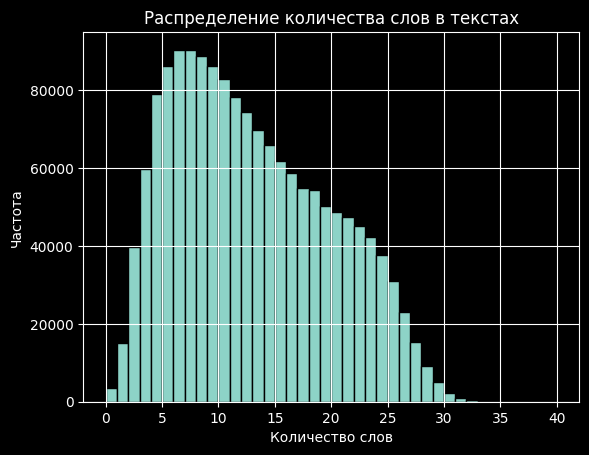

In [6]:
# гистограмма распределения длины
plt.hist(word_counts, bins=40, edgecolor='black')
plt.title("Распределение количества слов в текстах")
plt.xlabel("Количество слов")
plt.ylabel("Частота")
plt.grid(True)
plt.show()

In [ ]:
min_length = 3
max_length = 26

In [ ]:
data = data[np.array(word_counts) >= 3]
data = data.reset_index(drop=True)

In [ ]:
data.info()

In [ ]:
train_texts, val_test_texts = train_test_split(
    data, test_size=TEST_VAL_SIZE, random_state=RANDOM_STATE
)
val_texts, test_texts = train_test_split(
    val_test_texts, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

In [ ]:
print('Train size:', len(train_texts))
print('Validation size:', len(val_texts))
print('Test size:', len(test_texts))

In [ ]:
tokenizer: PreTrainedTokenizerBase = AutoTokenizer.from_pretrained(MODEL_NAME)

In [ ]:
train_dataset = TrainDataset(texts=train_texts['text'].tolist(), tokenizer=tokenizer, max_length=max_length)
val_dataset = EvalDataset(texts=val_texts['text'].tolist(), tokenizer=tokenizer, max_length=max_length)
test_dataset = EvalDataset(texts=test_texts['text'].tolist(), tokenizer=tokenizer, max_length=max_length)

In [ ]:
def collate_fn(batch):
    inputs = [torch.tensor(item["input_ids"]) for item in batch]
    labels = [torch.tensor(item["labels"]) for item in batch]

    lengths = torch.tensor([len(x) for x in inputs])

    inputs = pad_sequence(inputs, batch_first=True, padding_value=PADDING_VALUE)
    labels = pad_sequence(labels, batch_first=True, padding_value=PADDING_VALUE)

    return  {
        'input_ids': inputs.to(get_device()),
        'labels': labels.to(get_device()),
        'lengths': lengths.cpu()
    }

In [ ]:
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

In [ ]:
model = SequencePredictionLSTM(
    vocab_size=len(tokenizer.get_vocab()),
    embedding_dim=LSTM_HIDDEN_STATE,
    hidden_size=LSTM_HIDDEN_STATE,
    padding_idx=PADDING_VALUE
)
model.to(get_device())

In [ ]:
criterion = nn.CrossEntropyLoss(ignore_index=PADDING_VALUE)
optimizer = Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

train(
    model=model,
    n_epochs=EPOCHS,
    tokenizer=tokenizer,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    evaluate_func=compute_rouge_score,
    max_length=max_length
)

In [ ]:
save_model_dict(model)